# Data misfit in the measurement's own coordinates

For one hkl ring the data are intensity as a function of azimuth (eta), sample rotation (omega) and translation.
This notebook shows data and model prediction (adaptive and uniform reconstruction) in those coordinates,
instead of as detector images:

1. **eta-omega images of one ring**, summed over all translations (the whole sample diameter) and for the single
   translation where the beam passes through the rotation axis;
2. the same, summed over translations, for **every ring**;
3. **residuals** (data - prediction) of 1.;
4. **line profiles** along eta and along omega;
5. **sinograms** of the ring intensity (summed over eta): omega against translation;
6. **agreement against length scale**: correlation between data and prediction after both are smoothed in eta
   and omega by the same Gaussian. With a fixed kernel width `sigma` the model cannot reproduce the exact peak
   shape; this shows how much of the misfit sits at scales below the peak width and how much above;
7. per-ring correlation and relative residual.

The predictions are computed from the saved reconstructions (`reconstruction_{adaptive,uniform}.h5`) with the
same data reduction, weights, geometry and material as `texture_tomography/textomo_*.ipynb`, and cached in
`CACHE_DIR` (recomputed when the reconstruction file is newer than the cache). Figures are saved in `FIG_DIR`.

Zero-weight bins (along the rotation axis and in detector gaps) are not fitted and are shown grey.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "integration" / "frame_loader.py").is_file())
sys.path.insert(0, str(REPO))

import os
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from diffractom import Grid, Material, SinglePhaseForwardOperator
from diffractom.operators.single_phase_forward_operator import group_reflections_into_rings
from integration.frame_loader import OUTPUT_PATH, PROCESS
from integration.integrated_data import IntegratedData

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Palatino", "Georgia"],
    "font.size": 12,
})

## Parameters

In [2]:
GRIDS = ["adaptive", "uniform"]
FIG_DIR = os.path.join(PROCESS, "figures", "misfit")
CACHE_DIR = os.path.join(PROCESS, "misfit_cache")
DPI = 300

MAIN_RINGS = [0, 1, 2, 3]  # rings of the single-ring figures (index into data.rings)
GAMMA = 0.5                # power-law colour scale for intensities (1 = linear)
CMAP = "magma"
RES_CMAP = "RdBu_r"
MODEL_COLORS = {"adaptive": "#2a6fdb", "uniform": "#e0782b"}
MODEL_LABELS = {"adaptive": "TT-Adaptive", "uniform": "TT-Uniform"}

PROFILE_OMEGA_DEG = [45, 135, 225]  # omega of the eta line profiles
PROFILE_ETA_DEG = [0, 45, 135]      # eta of the omega line profiles (away from the zero-weight +-90 deg)
SMOOTH_FWHM_DEG = [0, 0.5, 1, 2, 3, 5, 8, 12]  # Gaussian smoothing in eta and omega for the scale analysis

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)


def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", pad_inches=0.05)
    print(f"saved {path}")

## Data and weights
Identical to `textomo_*.ipynb`: overlapping translations averaged (151 positions), the first 3000 frames summed
in groups of 6 (500 omega bins of 0.72 deg), each ring scaled to the same total intensity; zero weight within
10 deg of the rotation axis and in eta bins left (almost) empty by detector gaps.

In [3]:
data = IntegratedData(OUTPUT_PATH)  # polarization-corrected integration
assert data.polarization_corrected is True

N_FRAMES = 3000  # one full turn
OMEGA_BIN = 6    # frames per omega bin

t0 = time.perf_counter()
positions = np.round(data.translations, 4)
unique_positions = np.unique(positions)
n_omega = N_FRAMES // OMEGA_BIN
reduced = np.zeros((len(unique_positions), n_omega, data.n_eta, data.n_rings), dtype=np.float32)
count = np.zeros(len(unique_positions))
for t in range(data.n_translations):
    u = np.searchsorted(unique_positions, positions[t])
    reduced[u] += data.I[t, :N_FRAMES].reshape(n_omega, OMEGA_BIN, data.n_eta, data.n_rings).sum(axis=1)
    count[u] += 1
reduced /= count[:, None, None, None].astype(np.float32)

arr = np.ascontiguousarray(reduced.transpose(1, 0, 2, 3))  # (N_Omega, My, N_eta, N_theta)
del reduced
ring_sums = arr.sum(axis=(0, 1, 2), dtype=np.float64)
arr *= (ring_sums.sum() / ring_sums).astype(np.float32)
N_Omega, My, N_eta, N_theta = arr.shape
omega_step = float(np.median(np.diff(data.omega_deg)))
print(f"data {arr.shape} reduced in {time.perf_counter() - t0:.0f} s")

eta = data.eta_deg
weights = np.ones(arr.shape, dtype=np.float32)
weights[:, :, np.abs(np.abs(eta) - 90) < 10, :] = 0
profile = arr.mean(axis=(0, 1))
empty = profile < 0.05 * np.median(profile, axis=0, keepdims=True)
weights[:, :, empty] = 0
# the weights do not depend on omega or translation: one (N_eta, N_theta) mask holds them all
fitted = weights[0, 0] > 0
assert all((weights[i, j] > 0).tolist() == fitted.tolist() for i, j in [(0, 0), (N_Omega - 1, My - 1)])

omega_bin_deg = data.omega_deg[:N_FRAMES].reshape(n_omega, OMEGA_BIN).mean(axis=1)  # measured omega, bin centres
ring_labels = ["+".join("".join(str(abs(int(v))) for v in hkl) for hkl in ring) for ring in data.hkl]
print("rings:", ", ".join(f"{i}: {l}" for i, l in enumerate(ring_labels)))

data (500, 151, 360, 14) reduced in 5 s


rings: 0: 111, 1: 200, 2: 220, 3: 311, 4: 222, 5: 400, 6: 331, 7: 420, 8: 422, 9: 333+511, 10: 440, 11: 531, 12: 600+442, 13: 620


## Geometry and material
As in `textomo_*.ipynb`. The translation through the rotation axis is the one closest to the measured axis position.

In [4]:
rotation_axis_mm = float(np.load(os.path.join(PROCESS, "al1050_15pct_center_slice", "rotation_axis_com.npy")))
translation_step_mm = float(np.median(np.diff(unique_positions)))
OMEGA_OFFSET_DEG = 50.0

cfg = {
    "energy": 12.398 / data.wavelength_A,
    "Nx": 115,
    "Ny": 115,
    "My": My,
    "N_Omega": N_Omega,
    "N_eta": N_eta,
    "angle_range": [-OMEGA_OFFSET_DEG, N_FRAMES * omega_step - OMEGA_OFFSET_DEG],
    "cor_offset": -rotation_axis_mm / translation_step_mm,
    "eta_angle_range": [0, 360],
    "j_direction_0": [0, -1, 0],
    "k_direction_0": [0, 0, 1],
    "p_direction_0": [1, 0, 0],
    "detector_direction_origin": [0, 1, 0],
    "detector_direction_positive_90": [0, 0, 1],
}

lattice = data.material["lattice_params"]
hkl_list = np.array([hkl for ring in data.rings for hkl in ring["hkl"]])
mat = Material.from_lattice_parameters(
    a=lattice["a"], b=lattice["b"], c=lattice["c"],
    alpha=lattice["alpha"], beta=lattice["beta"], gamma=lattice["gamma"],
    symmetry_group="cubic",
    wavelength_A=data.wavelength_A,
    min_two_theta=0.0,
    max_two_theta=0.0,
    hkl_list=hkl_list,
)
rings = group_reflections_into_rings(mat)
assert len(rings) == N_theta

i_center = int(np.argmin(np.abs(unique_positions - rotation_axis_mm)))
print(f"rotation axis at dty = {rotation_axis_mm:.4f} mm -> translation {i_center} (dty = {unique_positions[i_center]:.4f} mm)")

rotation axis at dty = -0.0324 mm -> translation 72 (dty = -0.0300 mm)


## Predictions
The operator is rebuilt from the saved grid orientations and kernel width; the saved coefficients have their rows
flipped for display, which is undone here.

In [5]:
def predict(grid_name):
    recon_path = os.path.join(PROCESS, f"reconstruction_{grid_name}.h5")
    cache = os.path.join(CACHE_DIR, f"prediction_{grid_name}.npy")
    if os.path.isfile(cache) and os.path.getmtime(cache) > os.path.getmtime(recon_path):
        print(f"{grid_name}: cached prediction {cache}")
        return np.load(cache)
    with h5py.File(recon_path, "r") as f:
        coeffs = f["coeffs"][...]
        grid_mats = f["grid_mats"][...]
        attrs = dict(f.attrs)
    assert attrs["n_omega"] == N_Omega and attrs["n_eta"] == N_eta and np.isclose(attrs["cor_offset"], cfg["cor_offset"])
    t0 = time.perf_counter()
    grid = Grid.from_rotation_matrices(grid_mats, np.deg2rad(float(attrs["sigma_deg"])))
    op = SinglePhaseForwardOperator(cfg={**cfg, "Nx": int(attrs["Nx"]), "Ny": int(attrs["Ny"])}, material=mat,
                                    grid=grid, max_gb=1.0, verbose=False, normalized=True,
                                    reserve_coefficient_arrays=0,
                                    pf_mode="generated")  # applied once: the PF matrix is generated, not stored
    pred = op.direct(coeffs).reshape(N_Omega, My, N_eta, N_theta)  # coeffs: (K, Ny, Nx), as saved
    del op
    np.save(cache, pred)
    print(f"{grid_name}: K = {attrs['K']}, sigma = {attrs['sigma_deg']} deg, predicted in {time.perf_counter() - t0:.0f} s")
    return pred


pred = {g: predict(g) for g in GRIDS}
sigma_deg = {}
for g in GRIDS:
    with h5py.File(os.path.join(PROCESS, f"reconstruction_{g}.h5"), "r") as f:
        sigma_deg[g] = float(f.attrs["sigma_deg"])

wnorm = np.sqrt(np.sum((weights * arr) ** 2, dtype=np.float64))
for g in GRIDS:
    res = np.sqrt(np.sum((weights * (arr - pred[g])) ** 2, dtype=np.float64)) / wnorm
    print(f"{MODEL_LABELS[g]}: relative weighted residual {res:.3f}")

adaptive: cached prediction /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/misfit_cache/prediction_adaptive.npy


uniform: K = 82198, sigma = 2.0 deg, predicted in 51 s


TT-Adaptive: relative weighted residual 0.397


TT-Uniform: relative weighted residual 0.773


## Helpers

In [6]:
def eta_omega(a, ring, trans=None):
    # (N_Omega, N_eta) image of one ring: summed over translations, or one translation
    img = a[:, :, :, ring].sum(axis=1, dtype=np.float64) if trans is None else a[:, trans, :, ring].astype(np.float64)
    return np.where(fitted[:, ring][None, :], img, np.nan)


def corr(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    return float(np.corrcoef(x[ok], y[ok])[0, 1])


EXTENT = [eta[0] - 0.5, eta[-1] + 0.5, omega_bin_deg[-1], omega_bin_deg[0]]


def show(ax, img, norm, cmap=CMAP):
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad("0.75")
    return ax.imshow(img, extent=EXTENT, aspect="auto", interpolation="nearest", cmap=cm, norm=norm)


def label_axes(ax, left=True, bottom=True):
    if bottom:
        ax.set_xlabel("Azimuth η (°)")
        ax.set_xticks([-180, -90, 0, 90, 180])
    if left:
        ax.set_ylabel("Rotation ω (°)")

## Figure 1: one ring, eta against omega
Rows: data, TT-Adaptive, TT-Uniform. Left: summed over all translations (the whole sample diameter). Right: the
translation through the rotation axis. One colour scale per column (power law, `GAMMA`); grey: zero weight.
The number in each title is the correlation with the data.

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/eta_omega_ring0_111.png


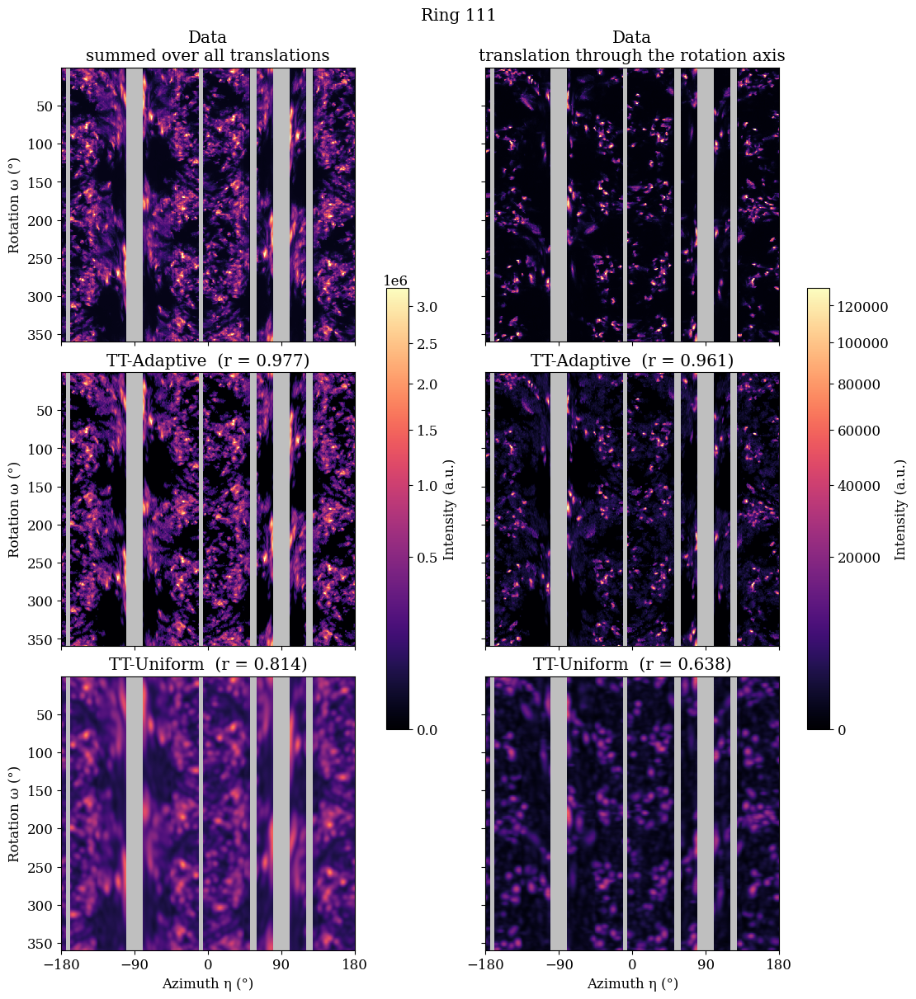

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/eta_omega_ring1_200.png


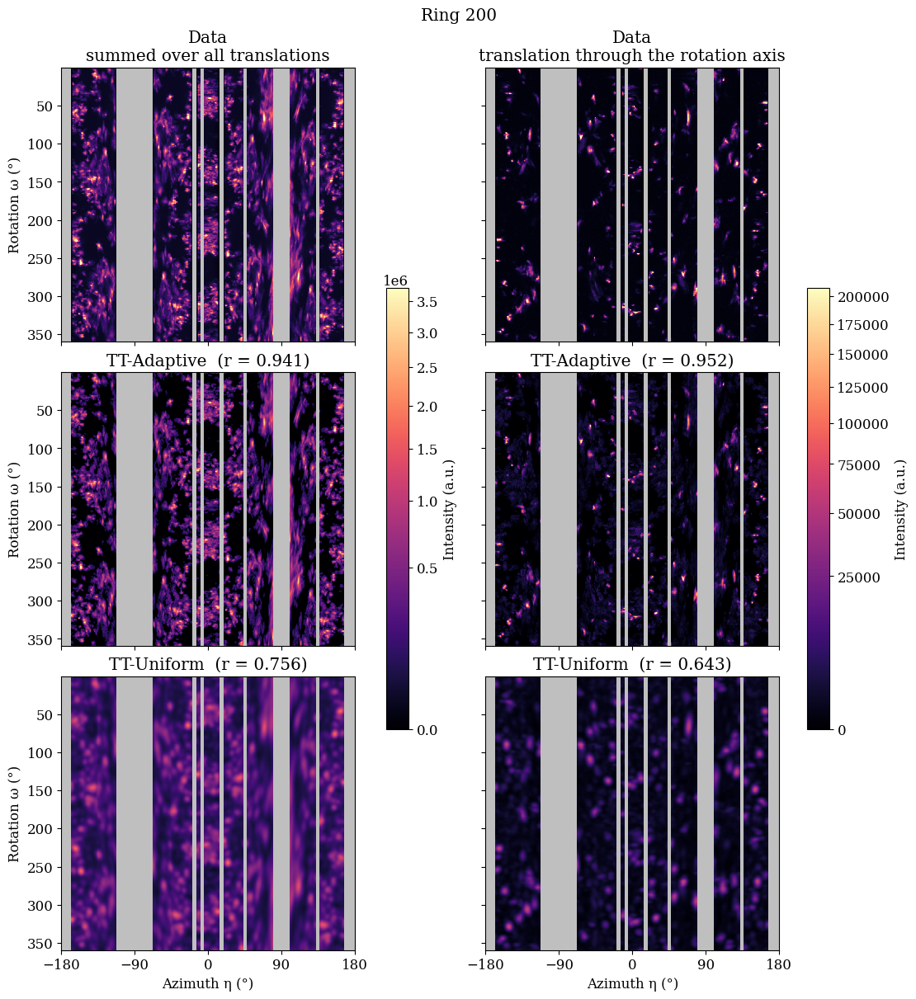

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/eta_omega_ring2_220.png


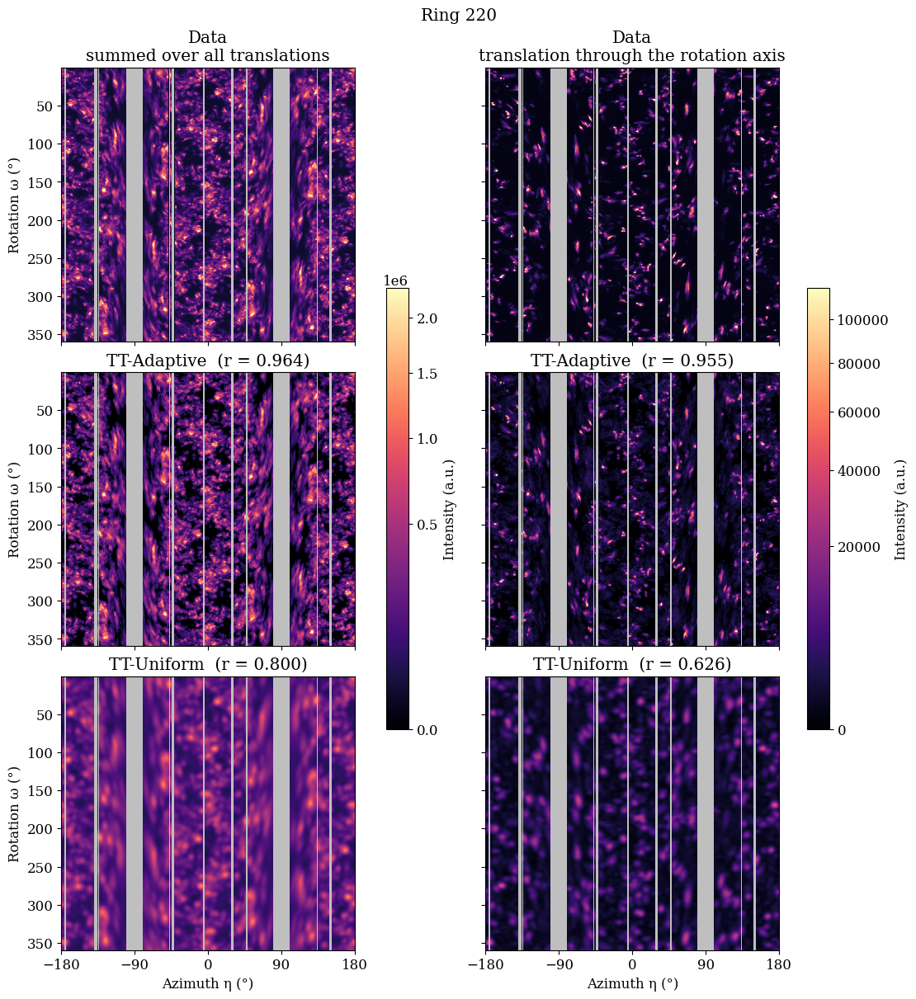

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/eta_omega_ring3_311.png


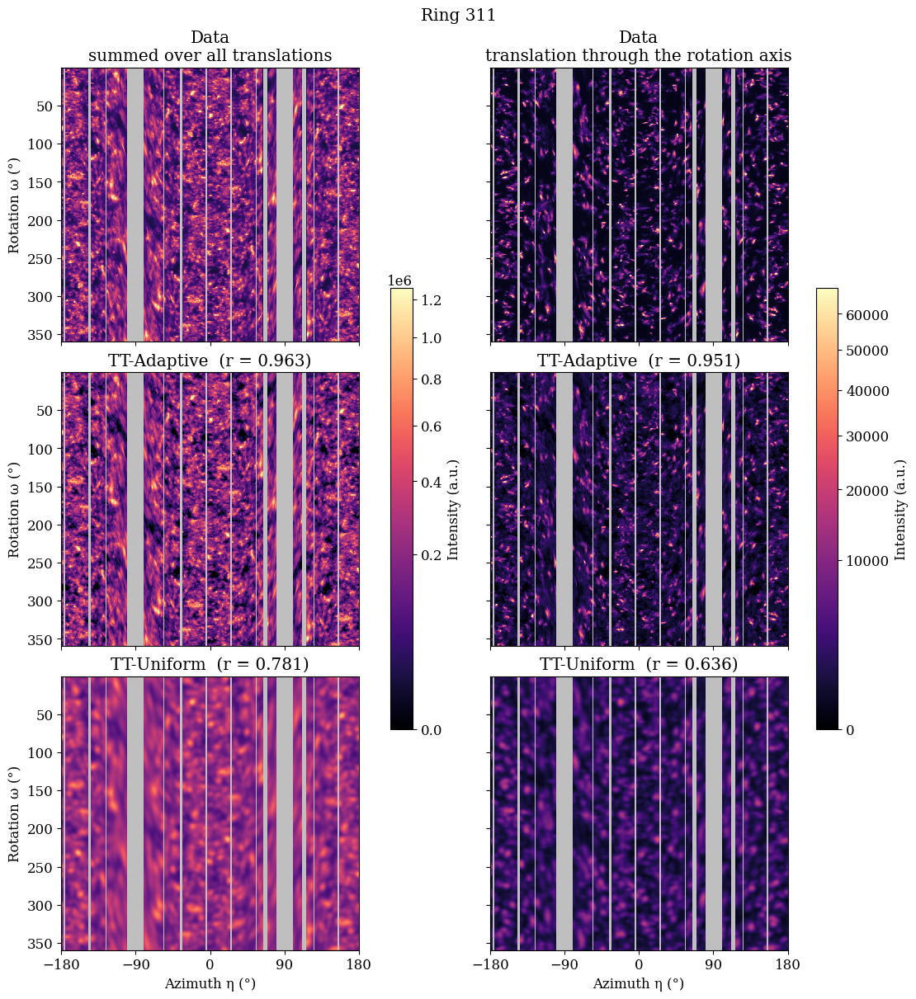

In [7]:
def ring_figure(ring):
    cols = [("summed over all translations", None), (f"translation through the rotation axis", i_center)]
    fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True, sharey=True, constrained_layout=True)
    for c, (col_title, trans) in enumerate(cols):
        d = eta_omega(arr, ring, trans)
        norm = mcolors.PowerNorm(GAMMA, vmin=0, vmax=np.nanpercentile(d, 99.9))
        for r, (name, a) in enumerate([("Data", arr)] + [(MODEL_LABELS[g], pred[g]) for g in GRIDS]):
            img = eta_omega(a, ring, trans)
            im = show(axes[r, c], img, norm)
            title = name if r == 0 else f"{name}  (r = {corr(img, d):.3f})"
            axes[r, c].set_title(f"{title}\n{col_title}" if r == 0 else title)
            label_axes(axes[r, c], left=c == 0, bottom=r == 2)
        fig.colorbar(im, ax=axes[:, c], shrink=0.5, label="Intensity (a.u.)")
    fig.suptitle(f"Ring {ring_labels[ring]}")
    return fig


for ring in MAIN_RINGS:
    fig = ring_figure(ring)
    save_fig(fig, f"eta_omega_ring{ring}_{ring_labels[ring]}.png")
    plt.show()

## Paper panels: ring 111
Data, TT-Adaptive and TT-Uniform on one colour scale, for the translation through the rotation axis (`center`)
and summed over all translations (`summed`), each view with its own colour scale. As SVG with editable text
(for Inkscape): each panel on its own, the colour bar on its own, and the three side by side with the colour
bar. Saved in `PAPER_DIR` (`visualization/figures/`, not version controlled).

TT-Adaptive: r = 0.961
TT-Uniform: r = 0.638


saved /zhome/71/c/146676/texture_tomography/visualization/figures/eta_omega_ring0_111_center_data.svg


saved /zhome/71/c/146676/texture_tomography/visualization/figures/eta_omega_ring0_111_center_adaptive.svg


saved /zhome/71/c/146676/texture_tomography/visualization/figures/eta_omega_ring0_111_center_uniform.svg
saved /zhome/71/c/146676/texture_tomography/visualization/figures/eta_omega_ring0_111_center_colorbar.svg


saved /zhome/71/c/146676/texture_tomography/visualization/figures/eta_omega_ring0_111_center.svg


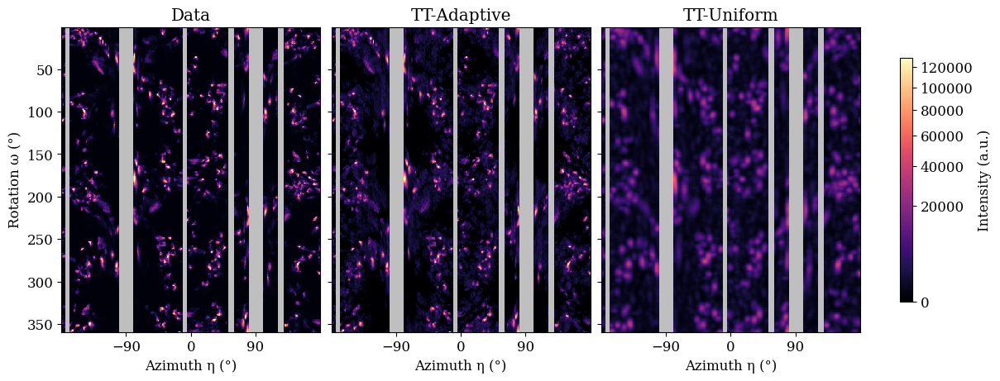

In [8]:
PAPER_DIR = os.path.join(REPO, "visualization", "figures")
PAPER_RING = 0  # 111
PAPER_VIEWS = {"center": i_center, "summed": None}  # translation index, or None: summed over all translations
os.makedirs(PAPER_DIR, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # text stays text in the SVG


def paper_panel(ax, img, norm, title, left):
    im = show(ax, img, norm)
    ax.set_title(title)
    label_axes(ax, left=left)
    ax.set_xticks([-90, 0, 90])  # no labels at +-180, where neighbouring panels meet
    return im


def save_svg(fig, name):
    path = os.path.join(PAPER_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", pad_inches=0.05)
    print(f"saved {path}")


panels = [("data", "Data", arr)] + [(g, MODEL_LABELS[g], pred[g]) for g in GRIDS]
for view, trans in PAPER_VIEWS.items():
    imgs = {key: eta_omega(a, PAPER_RING, trans) for key, _, a in panels}
    norm = mcolors.PowerNorm(GAMMA, vmin=0, vmax=np.nanpercentile(imgs["data"], 99.9))
    tag = f"ring{PAPER_RING}_{ring_labels[PAPER_RING]}_{view}"
    for g in GRIDS:
        print(f"{view}: {MODEL_LABELS[g]}: r = {corr(imgs[g], imgs['data']):.3f}")

    for key, title, _ in panels:
        fig, ax = plt.subplots(figsize=(4, 4.5), constrained_layout=True)
        paper_panel(ax, imgs[key], norm, title, left=True)
        save_svg(fig, f"eta_omega_{tag}_{key}.svg")
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(0.35, 3.5))
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=CMAP), cax=ax, label="Intensity (a.u.)")
    save_svg(fig, f"eta_omega_{tag}_colorbar.svg")
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True, constrained_layout=True)
    for n, (ax, (key, title, _)) in enumerate(zip(axes, panels)):
        im = paper_panel(ax, imgs[key], norm, title, left=n == 0)
    fig.colorbar(im, ax=axes, shrink=0.8, label="Intensity (a.u.)")
    save_svg(fig, f"eta_omega_{tag}.svg")
    plt.show()

## Figure 2: every ring, summed over translations
Columns: data, TT-Adaptive, TT-Uniform; one colour scale per row.

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/eta_omega_all_rings.png


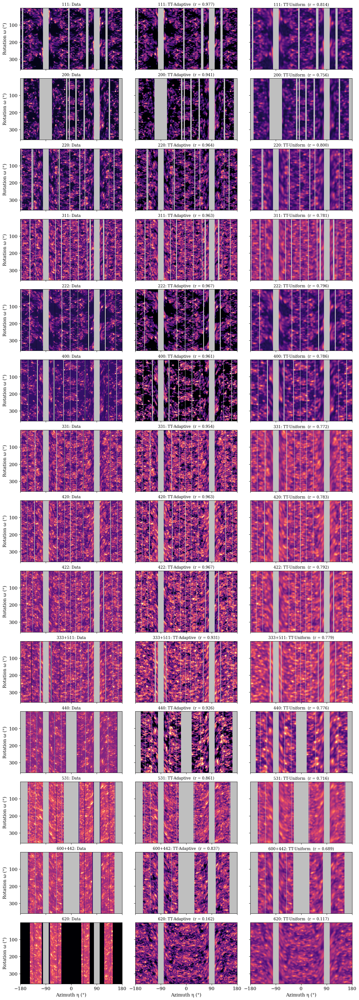

In [9]:
fig, axes = plt.subplots(N_theta, 3, figsize=(13, 2.6 * N_theta), sharex=True, sharey=True, constrained_layout=True)
for ring in range(N_theta):
    d = eta_omega(arr, ring)
    norm = mcolors.PowerNorm(GAMMA, vmin=0, vmax=np.nanpercentile(d, 99.9))
    for c, (name, a) in enumerate([("Data", arr)] + [(MODEL_LABELS[g], pred[g]) for g in GRIDS]):
        img = eta_omega(a, ring)
        show(axes[ring, c], img, norm)
        extra = "" if c == 0 else f"  (r = {corr(img, d):.3f})"
        axes[ring, c].set_title(f"{ring_labels[ring]}: {name}{extra}", fontsize=10)
        label_axes(axes[ring, c], left=c == 0, bottom=ring == N_theta - 1)
save_fig(fig, "eta_omega_all_rings.png")
plt.show()

## Figure 3: residuals, data - prediction
For the rings of Figure 1, summed over translations and for the central translation. The colour scale is
symmetric and set by the data maximum, so the residual reads as a fraction of the signal.

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/residual_ring0_111.png


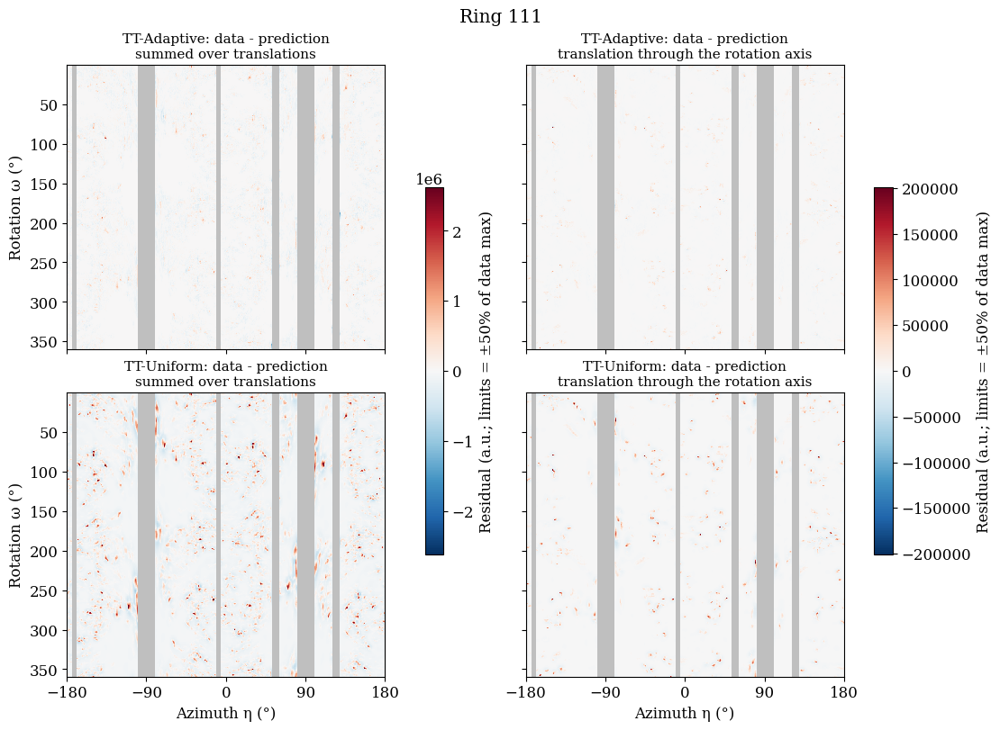

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/residual_ring1_200.png


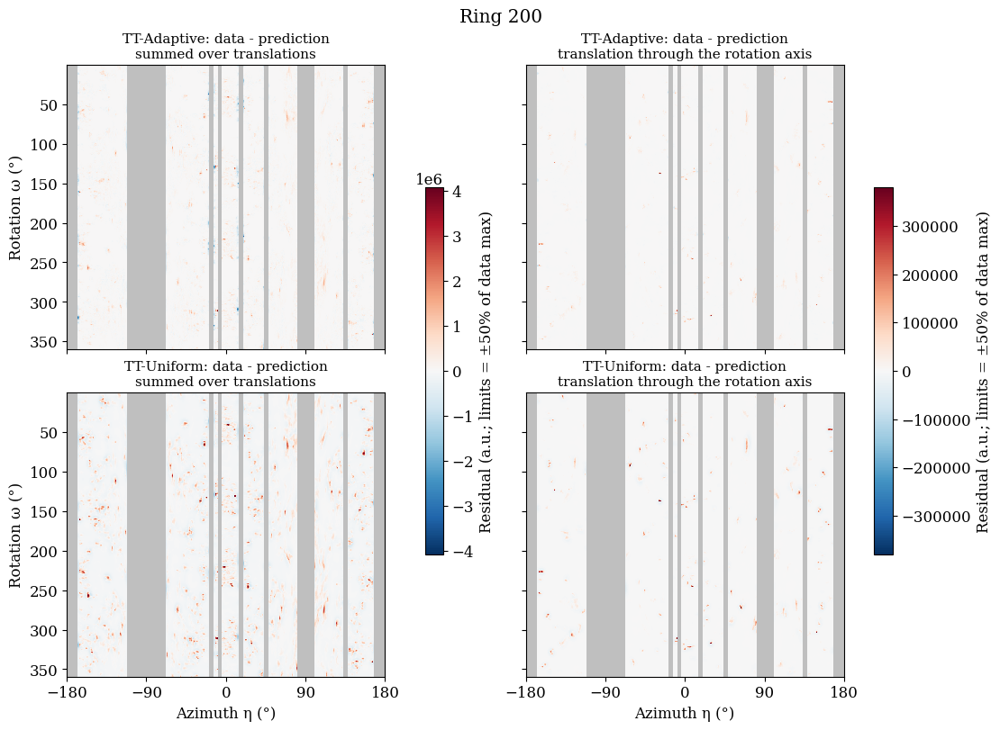

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/residual_ring2_220.png


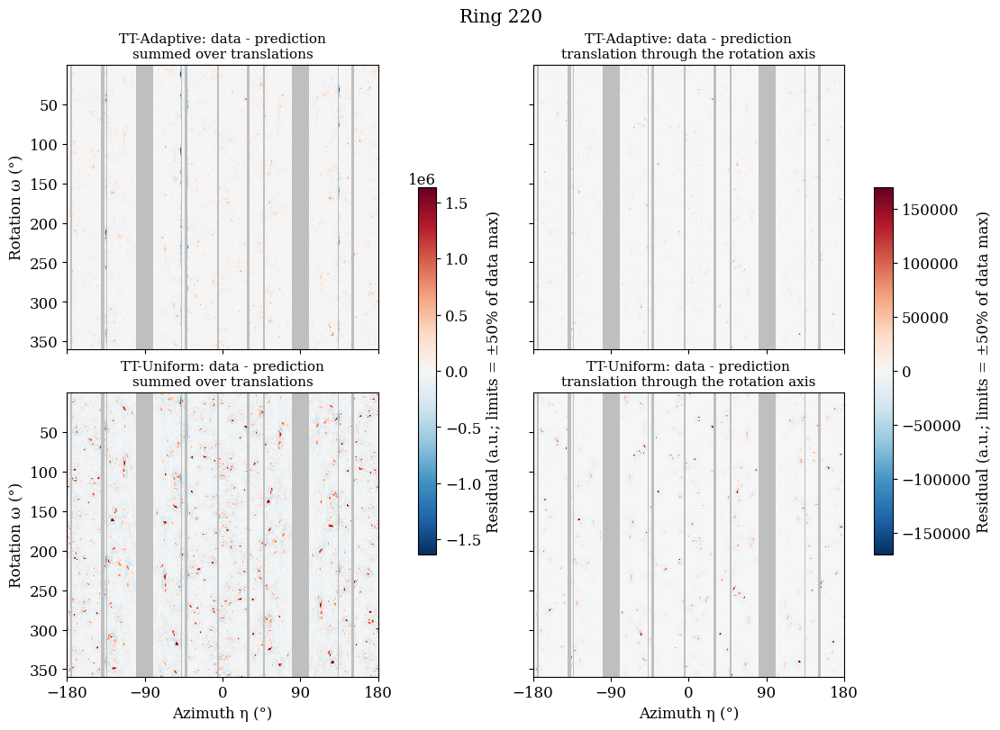

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/residual_ring3_311.png


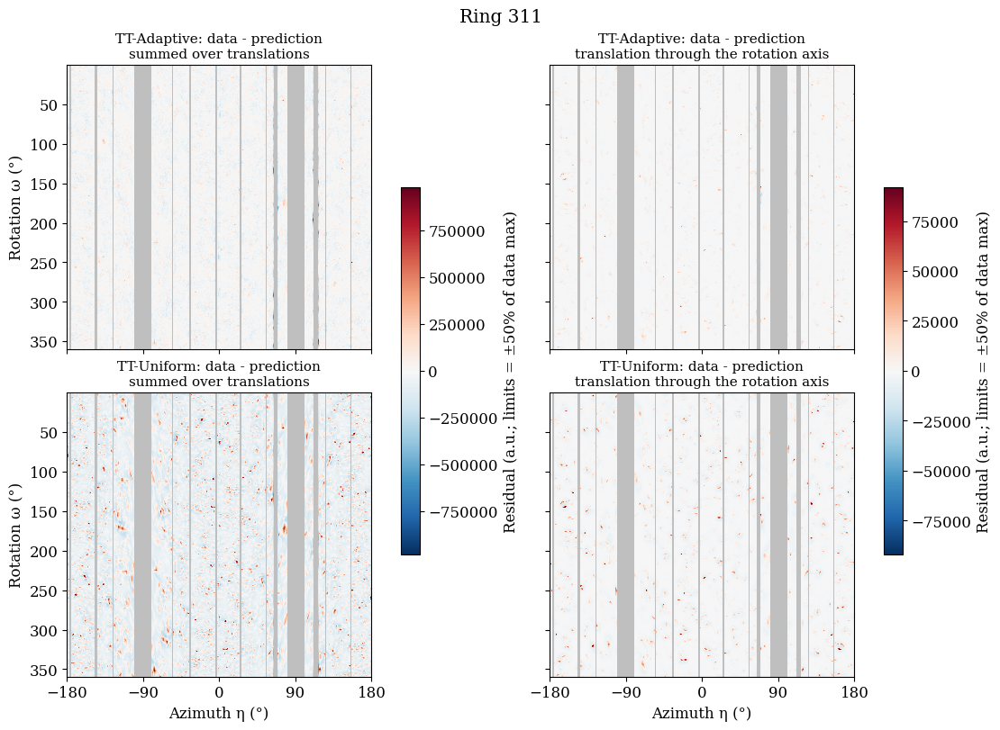

In [10]:
for ring in MAIN_RINGS:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True, constrained_layout=True)
    for c, trans in enumerate([None, i_center]):
        d = eta_omega(arr, ring, trans)
        vmax = 0.5 * np.nanmax(d)
        for r, g in enumerate(GRIDS):
            im = show(axes[r, c], d - eta_omega(pred[g], ring, trans),
                      mcolors.Normalize(-vmax, vmax), cmap=RES_CMAP)
            where = "summed over translations" if trans is None else "translation through the rotation axis"
            axes[r, c].set_title(f"{MODEL_LABELS[g]}: data - prediction\n{where}", fontsize=11)
            label_axes(axes[r, c], left=c == 0, bottom=r == 1)
        fig.colorbar(im, ax=axes[:, c], shrink=0.6, label="Residual (a.u.; limits = ±50% of data max)")
    fig.suptitle(f"Ring {ring_labels[ring]}")
    save_fig(fig, f"residual_ring{ring}_{ring_labels[ring]}.png")
    plt.show()

## Figure 4: line profiles
Ring `MAIN_RINGS[0]`, translation through the rotation axis. Top: intensity against eta at fixed omega; bottom:
against omega at fixed eta. Grey bands: zero weight.

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/profiles_ring0_111.png


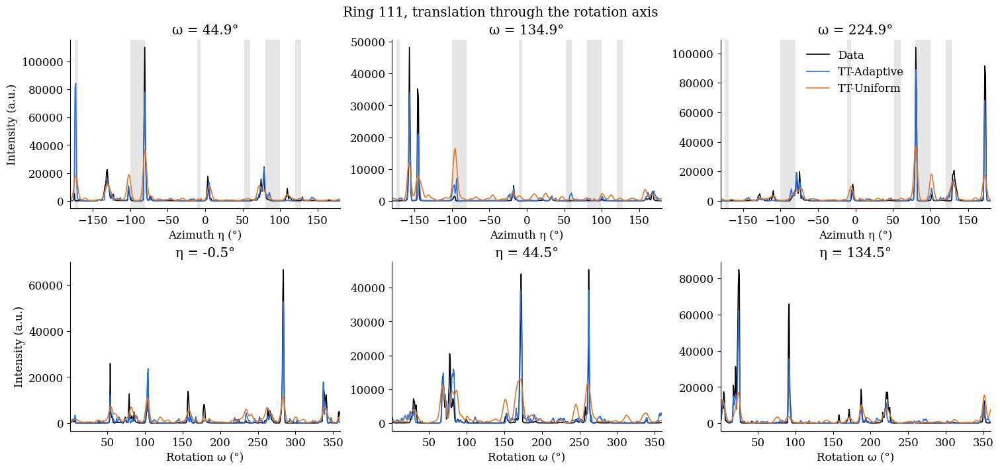

In [11]:
ring = MAIN_RINGS[0]
fig, axes = plt.subplots(2, len(PROFILE_OMEGA_DEG), figsize=(15, 7), constrained_layout=True)
for c, om in enumerate(PROFILE_OMEGA_DEG):
    i = int(np.argmin(np.abs(omega_bin_deg - om)))
    ax = axes[0, c]
    ax.plot(eta, arr[i, i_center, :, ring], color="black", lw=1.2, label="Data")
    for g in GRIDS:
        ax.plot(eta, pred[g][i, i_center, :, ring], color=MODEL_COLORS[g], lw=1.2, label=MODEL_LABELS[g])
    ax.set_title(f"ω = {omega_bin_deg[i]:.1f}°")
    ax.set_xlabel("Azimuth η (°)")
    ax.set_xlim(-180, 180)
for c, et in enumerate(PROFILE_ETA_DEG):
    j = int(np.argmin(np.abs(eta - et)))
    ax = axes[1, c]
    ax.plot(omega_bin_deg, arr[:, i_center, j, ring], color="black", lw=1.2, label="Data")
    for g in GRIDS:
        ax.plot(omega_bin_deg, pred[g][:, i_center, j, ring], color=MODEL_COLORS[g], lw=1.2, label=MODEL_LABELS[g])
    ax.set_title(f"η = {eta[j]:.1f}°" + ("" if fitted[j, ring] else " (zero weight)"))
    ax.set_xlabel("Rotation ω (°)")
    ax.set_xlim(omega_bin_deg[0], omega_bin_deg[-1])
for ax in axes[0]:
    for j in np.flatnonzero(~fitted[:, ring]):
        ax.axvspan(eta[j] - 0.5, eta[j] + 0.5, color="0.9", lw=0, zorder=0)
for ax in axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylabel("Intensity (a.u.)")
axes[1, 0].set_ylabel("Intensity (a.u.)")
axes[0, -1].legend(frameon=False)
fig.suptitle(f"Ring {ring_labels[ring]}, translation through the rotation axis")
save_fig(fig, f"profiles_ring{ring}_{ring_labels[ring]}.png")
plt.show()

## Figure 5: sinograms of the ring intensity
Intensity summed over the fitted eta bins of one ring: omega against translation. This is the spatial
information the reconstruction draws on, independent of the peak shape in eta.

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/sinograms.png


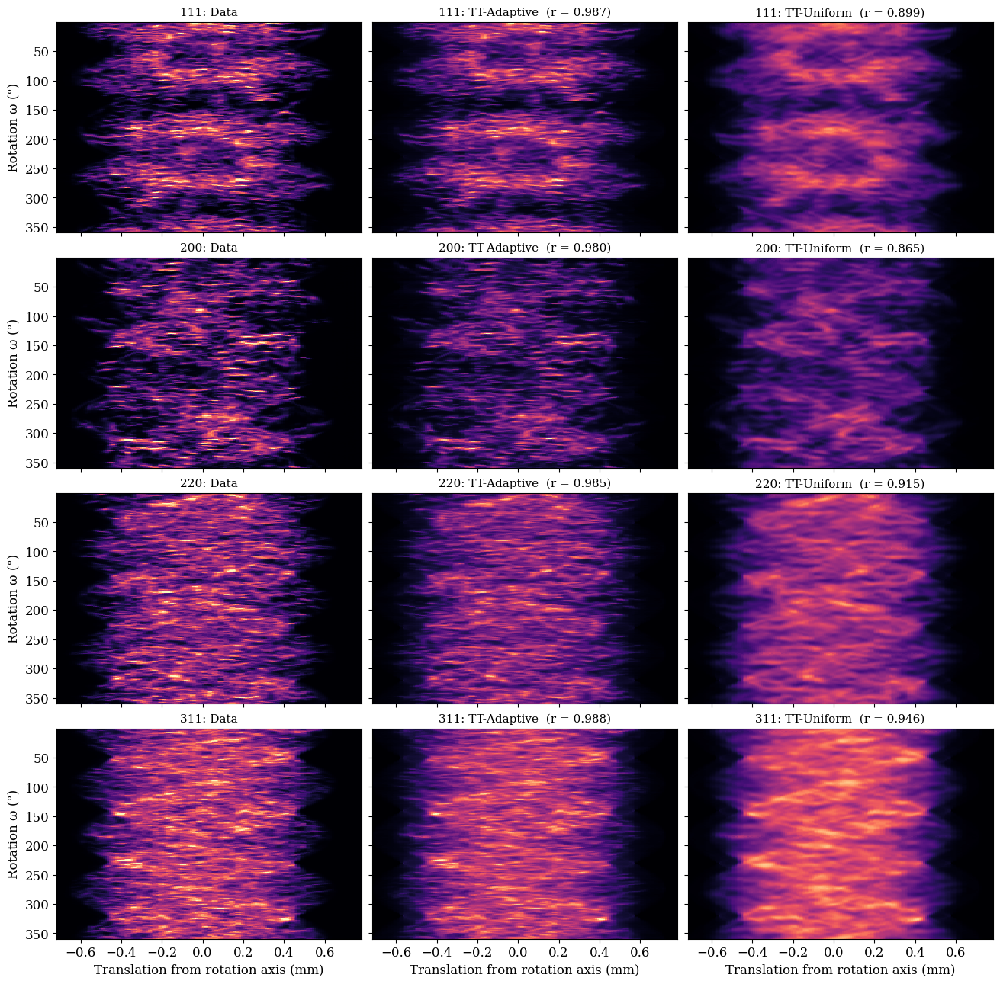

In [12]:
fig, axes = plt.subplots(len(MAIN_RINGS), 3, figsize=(13, 3.2 * len(MAIN_RINGS)), sharex=True, sharey=True,
                         constrained_layout=True)
sino_extent = [unique_positions[0] - rotation_axis_mm, unique_positions[-1] - rotation_axis_mm,
               omega_bin_deg[-1], omega_bin_deg[0]]
for r, ring in enumerate(MAIN_RINGS):
    sino = {name: (a[:, :, fitted[:, ring], ring]).sum(axis=2, dtype=np.float64)
            for name, a in [("Data", arr)] + [(MODEL_LABELS[g], pred[g]) for g in GRIDS]}
    vmax = np.percentile(sino["Data"], 99.9)
    for c, (name, s) in enumerate(sino.items()):
        axes[r, c].imshow(s, extent=sino_extent, aspect="auto", interpolation="nearest", cmap=CMAP, vmin=0, vmax=vmax)
        extra = "" if c == 0 else f"  (r = {corr(s, sino['Data']):.3f})"
        axes[r, c].set_title(f"{ring_labels[ring]}: {name}{extra}", fontsize=11)
        if r == len(MAIN_RINGS) - 1:
            axes[r, c].set_xlabel("Translation from rotation axis (mm)")
    axes[r, 0].set_ylabel("Rotation ω (°)")
save_fig(fig, "sinograms.png")
plt.show()

## Figure 6: agreement against length scale
Data and prediction are smoothed by the same Gaussian in eta and omega (full width at half maximum on the
x axis; both angles are periodic over the full turn), and compared over all fitted bins of all rings and
translations. Smoothing removes the detail below its width: if the misfit is mostly in the peak shape (a
fixed kernel width cannot reproduce the width of every peak), the agreement rises quickly with the smoothing
width. The dashed lines mark the kernel width `sigma` of each basis, as a full width at half maximum, for
orientation (a misorientation moves a diffraction spot by at most about the same angle).

scale analysis in 866 s
TT-Adaptive: correlation 0°: 0.913, 0.5°: 0.929, 1°: 0.931, 2°: 0.929, 3°: 0.922, 5°: 0.908, 8°: 0.892, 12°: 0.883
TT-Uniform: correlation 0°: 0.615, 0.5°: 0.718, 1°: 0.778, 2°: 0.847, 3°: 0.873, 5°: 0.889, 8°: 0.886, 12°: 0.883


saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/agreement_vs_scale.png


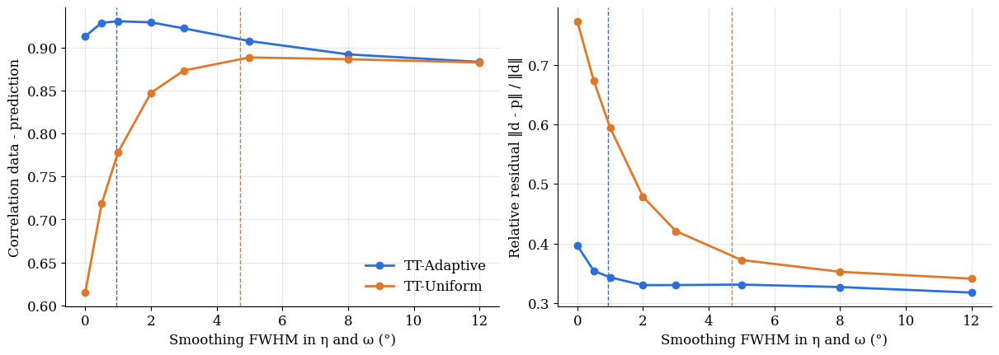

In [13]:
def smooth(x, fwhm_deg):
    # Gaussian smoothing along omega (axis 0) and eta (axis 2), both periodic
    if fwhm_deg == 0:
        return x
    s = fwhm_deg / 2.3548
    x = gaussian_filter1d(x, s / omega_step, axis=0, mode="wrap")
    return gaussian_filter1d(x, s / (eta[1] - eta[0]), axis=2, mode="wrap")


t0 = time.perf_counter()
# running sums for the Pearson correlation and the relative residual, pooled over rings
stats = {g: np.zeros((len(SMOOTH_FWHM_DEG), 6)) for g in GRIDS}  # n, sx, sy, sxx, syy, sxy
for ring in range(N_theta):
    m = fitted[:, ring]
    d_ring = arr[:, :, :, ring] * m  # zero-weight bins are zero in data and prediction alike
    p_ring = {g: pred[g][:, :, :, ring] * m for g in GRIDS}
    for k, f in enumerate(SMOOTH_FWHM_DEG):
        x = smooth(d_ring, f)[:, :, m].astype(np.float64).ravel()
        for g in GRIDS:
            y = smooth(p_ring[g], f)[:, :, m].astype(np.float64).ravel()
            stats[g][k] += [x.size, x.sum(), y.sum(), x @ x, y @ y, x @ y]
print(f"scale analysis in {time.perf_counter() - t0:.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for g in GRIDS:
    n, sx, sy, sxx, syy, sxy = stats[g].T
    r = (sxy - sx * sy / n) / np.sqrt((sxx - sx ** 2 / n) * (syy - sy ** 2 / n))
    rel = np.sqrt(sxx - 2 * sxy + syy) / np.sqrt(sxx)
    for ax, v in zip(axes, (r, rel)):
        ax.plot(SMOOTH_FWHM_DEG, v, "o-", color=MODEL_COLORS[g], lw=2, ms=6, label=MODEL_LABELS[g])
        ax.axvline(2.3548 * sigma_deg[g], color=MODEL_COLORS[g], ls="--", lw=1)
    print(f"{MODEL_LABELS[g]}: correlation " + ", ".join(f"{f:g}°: {v:.3f}" for f, v in zip(SMOOTH_FWHM_DEG, r)))
axes[0].set_ylabel("Correlation data - prediction")
axes[1].set_ylabel("Relative residual ‖d - p‖ / ‖d‖")
for ax in axes:
    ax.set_xlabel("Smoothing FWHM in η and ω (°)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
axes[0].legend(frameon=False)
save_fig(fig, "agreement_vs_scale.png")
plt.show()

## Figure 7: per ring
Correlation between data and prediction per ring, for the full data (every translation, omega and eta bin),
the translation-summed eta-omega image (Figure 2) and the sinogram (Figure 5).

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/misfit/correlation_per_ring.png


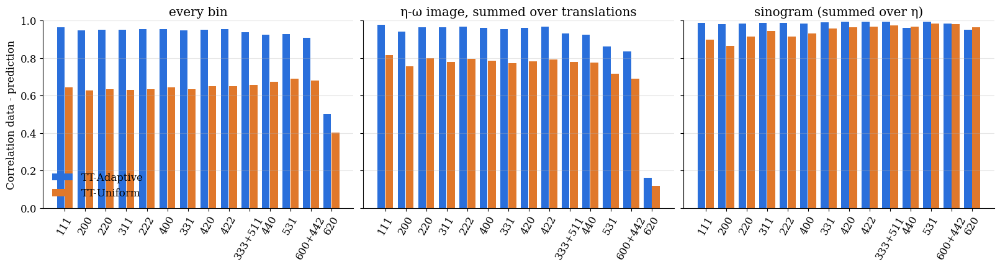

TT-Adaptive [[0.964, 0.977, 0.987], [0.947, 0.941, 0.98], [0.953, 0.964, 0.985], [0.951, 0.963, 0.988], [0.955, 0.967, 0.988], [0.954, 0.961, 0.985], [0.948, 0.954, 0.992], [0.951, 0.963, 0.993], [0.954, 0.967, 0.993], [0.94, 0.931, 0.993], [0.923, 0.926, 0.962], [0.928, 0.861, 0.993], [0.909, 0.837, 0.985], [0.501, 0.162, 0.95]]
TT-Uniform [[0.645, 0.814, 0.899], [0.626, 0.756, 0.865], [0.635, 0.8, 0.915], [0.632, 0.781, 0.946], [0.635, 0.796, 0.914], [0.644, 0.786, 0.931], [0.634, 0.772, 0.959], [0.651, 0.783, 0.965], [0.652, 0.792, 0.968], [0.656, 0.779, 0.975], [0.675, 0.776, 0.969], [0.689, 0.716, 0.983], [0.681, 0.689, 0.982], [0.401, 0.117, 0.964]]


In [14]:
per_ring = {g: np.zeros((N_theta, 3)) for g in GRIDS}
for ring in range(N_theta):
    m = fitted[:, ring]
    d_full = arr[:, :, m, ring]
    d_sum, d_sino = eta_omega(arr, ring), d_full.sum(axis=2, dtype=np.float64)
    for g in GRIDS:
        p_full = pred[g][:, :, m, ring]
        per_ring[g][ring] = [corr(d_full.ravel(), p_full.ravel()), corr(d_sum, eta_omega(pred[g], ring)),
                             corr(d_sino, p_full.sum(axis=2, dtype=np.float64))]

titles = ["every bin", "η-ω image, summed over translations", "sinogram (summed over η)"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True, constrained_layout=True)
x = np.arange(N_theta)
for c, ax in enumerate(axes):
    for i, g in enumerate(GRIDS):
        ax.bar(x + (i - 0.5) * 0.4, per_ring[g][:, c], width=0.38, color=MODEL_COLORS[g], label=MODEL_LABELS[g])
    ax.set_xticks(x)
    ax.set_xticklabels(ring_labels, rotation=60)
    ax.set_title(titles[c])
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Correlation data - prediction")
axes[0].legend(frameon=False, loc="lower left")
save_fig(fig, "correlation_per_ring.png")
plt.show()
for g in GRIDS:
    print(MODEL_LABELS[g], np.round(per_ring[g], 3).tolist())